Showing 10 samples from Test Set...


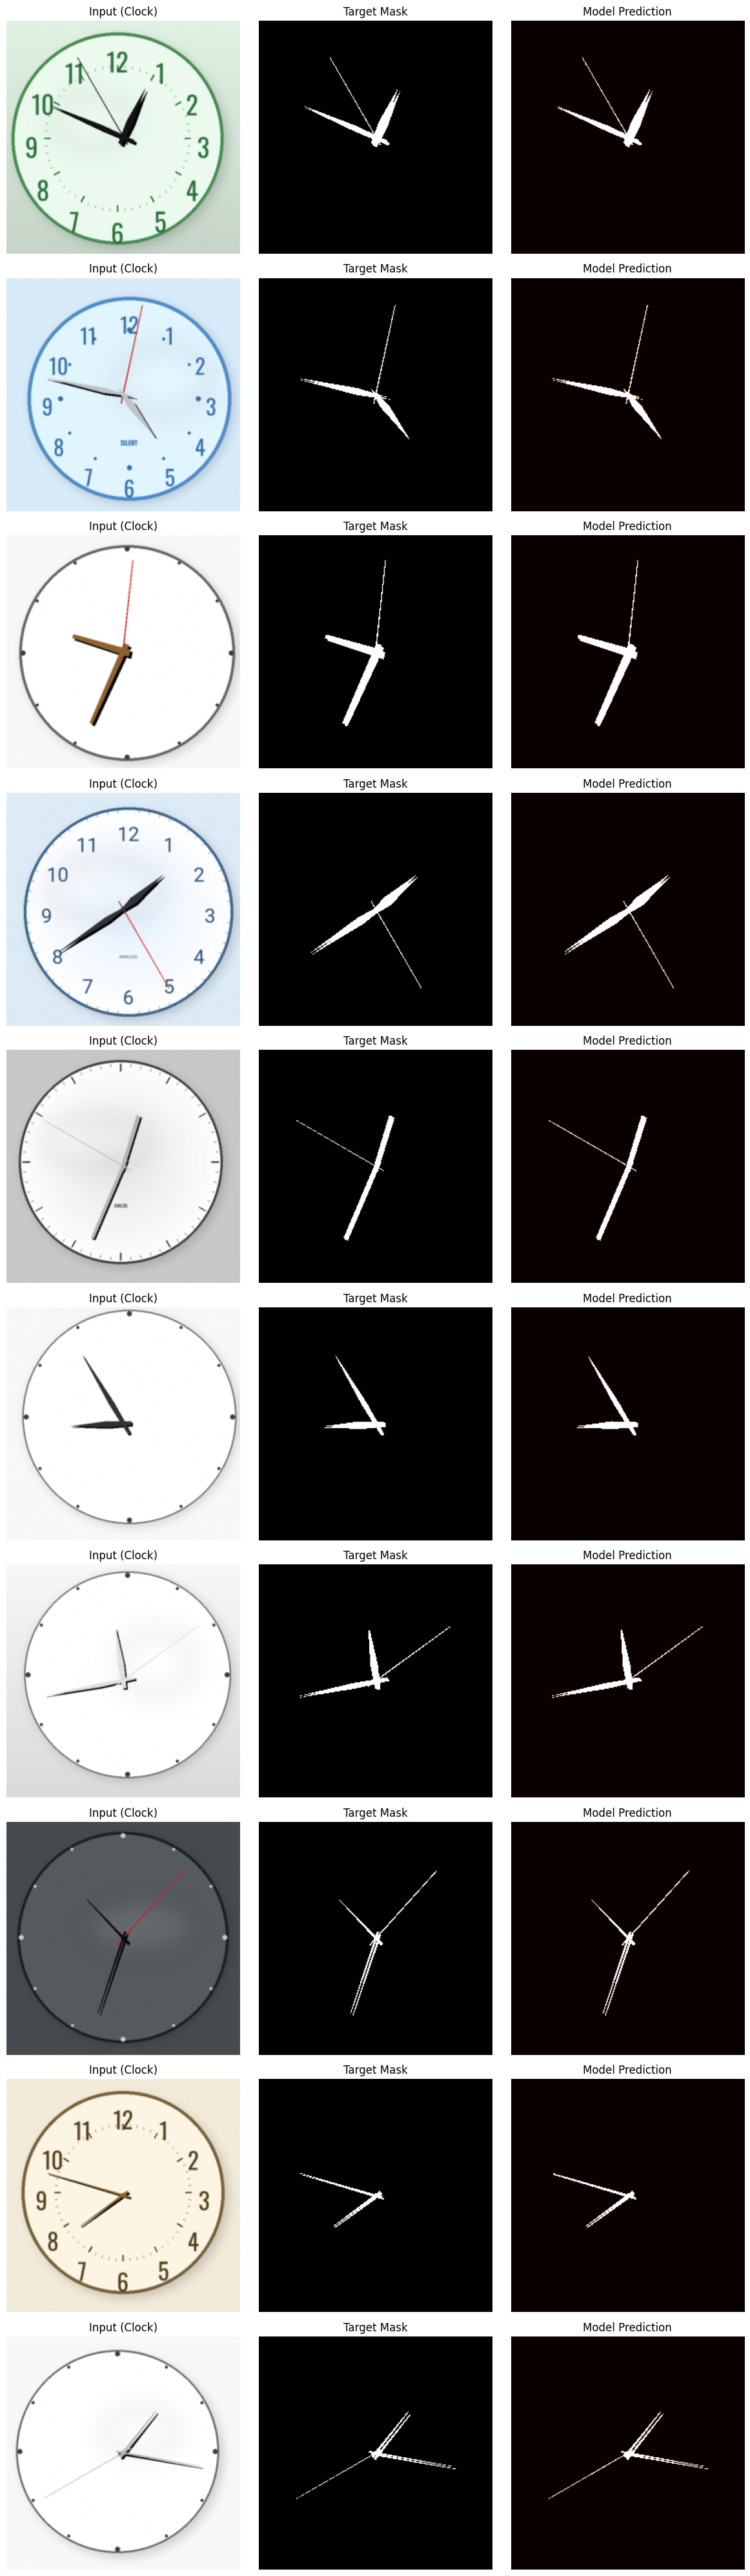

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from torch.utils.data import Dataset
import torchvision.io as io
import torchvision.transforms.functional as TF
import csv

# ==========================================
# 1. הגדרות ופרמטרים (תואם לקוד האימון)
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 256
DATA_DIR = Path("data")
TEST_CSV = DATA_DIR / "test_labels.csv"
CHECKPOINT_PATH = Path("outputs/checkpoints/best_mask_unet.pth")

# ערכי הנרמול של ImageNet
_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def normalize(t: torch.Tensor) -> torch.Tensor:
    return (t - _MEAN) / _STD

def denormalize(t: torch.Tensor) -> torch.Tensor:
    """מחזיר תמונה מנורמלת לטווח [0,1] לצורך תצוגה"""
    return (t * _STD + _MEAN).clamp(0, 1)

# ==========================================
# 2. הגדרת המודל (חובה לצורך טעינת המשקולות)
# ==========================================
class ResDoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.shortcut = (nn.Conv2d(in_ch, out_ch, 1, bias=False)
                         if in_ch != out_ch else nn.Identity())
    def forward(self, x): return self.block(x) + self.shortcut(x)

class MaskUNet(nn.Module):
    def __init__(self, base: int = 64):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1, self.e2, self.e3, self.e4 = ResDoubleConv(3, base), ResDoubleConv(base, base*2), ResDoubleConv(base*2, base*4), ResDoubleConv(base*4, base*8)
        self.bn = ResDoubleConv(base*8, base*16)
        self.up4, self.d4 = nn.ConvTranspose2d(base*16, base*8, 2, stride=2), ResDoubleConv(base*16, base*8)
        self.up3, self.d3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2), ResDoubleConv(base*8, base*4)
        self.up2, self.d2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2), ResDoubleConv(base*4, base*2)
        self.up1, self.d1 = nn.ConvTranspose2d(base*2, base, 2, stride=2), ResDoubleConv(base*2, base)
        self.head = nn.Sequential(nn.Conv2d(base, 1, 1), nn.Sigmoid())

    def forward(self, x):
        e1 = self.e1(x); e2 = self.e2(self.pool(e1)); e3 = self.e3(self.pool(e2)); e4 = self.e4(self.pool(e3)); b = self.bn(self.pool(e4))
        d = self.d4(torch.cat([self.up4(b), e4], dim=1))
        d = self.d3(torch.cat([self.up3(d), e3], dim=1))
        d = self.d2(torch.cat([self.up2(d), e2], dim=1))
        d = self.d1(torch.cat([self.up1(d), e1], dim=1))
        return self.head(d)

# ==========================================
# 3. מחלקת Dataset לבדיקה
# ==========================================
class SimpleTestDataset(Dataset):
    def __init__(self, csv_path):
        self.rows = []
        with open(csv_path, mode="r", encoding="utf-8") as f:
            for row in csv.DictReader(f): self.rows.append(row)
    def __len__(self): return len(self.rows)
    def __getitem__(self, idx):
        row = self.rows[idx]
        img = io.read_image(row["analog_path"])[:3].float() / 255.0
        mask = io.read_image(row["analog_without_hands_path"])[:1].float() / 255.0
        img = TF.resize(img, [IMAGE_SIZE, IMAGE_SIZE], antialias=True)
        mask = TF.resize(mask, [IMAGE_SIZE, IMAGE_SIZE], interpolation=TF.InterpolationMode.NEAREST)
        return normalize(img), (mask > 0.5).float()

# ==========================================
# 4. פונקציית ההצגה (Visualization)
# ==========================================
def show_inference_results(num_samples=5):
    if not CHECKPOINT_PATH.exists():
        print(f"Error: Model not found at {CHECKPOINT_PATH}")
        return

    # טעינת מודל ונתונים
    model = MaskUNet(base=64).to(DEVICE)
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    model.eval()
    
    ds = SimpleTestDataset(TEST_CSV)
    indices = np.random.choice(len(ds), min(num_samples, len(ds)), replace=False)

    fig, axes = plt.subplots(len(indices), 3, figsize=(12, 4 * len(indices)))
    if len(indices) == 1: axes = [axes]

    print(f"Showing {len(indices)} samples from Test Set...")

    with torch.no_grad():
        for i, idx in enumerate(indices):
            img_t, mask_t = ds[idx]
            
            # הרצת המודל
            pred_t = model(img_t.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()
            
            # המרה לתצוגה
            original_img = denormalize(img_t).permute(1, 2, 0).numpy()
            target_mask = mask_t.squeeze().numpy()
            prediction = pred_t.squeeze().numpy()
            
            # עמודה 1: מקור
            axes[i][0].imshow(original_img)
            axes[i][0].set_title("Input (Clock)")
            axes[i][0].axis("off")

            # עמודה 2: מסיכת מטרה (היכן שהמחוגים נמצאים)
            axes[i][1].imshow(target_mask, cmap="gray")
            axes[i][1].set_title("Target Mask")
            axes[i][1].axis("off")

            # עמודה 3: תחזית המודל
            axes[i][2].imshow(prediction, cmap="hot")
            axes[i][2].set_title("Model Prediction")
            axes[i][2].axis("off")

    plt.tight_layout()
    plt.show()

# הרצה
if __name__ == "__main__":
    show_inference_results(num_samples=10)